In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nflreadpy as nfl

In [169]:
from IPython.display import display

In [132]:
draft_url = "https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv"
draft = pd.read_csv(draft_url)

In [ ]:
draft = draft[(draft["season"] >= 2000) & (draft["season"] <= 2020)]
draft = draft[draft['w_av'].notna()]

position_order = ['DB', 'WR', 'LB', 'DE', 'DT', 'RB', 'T', 'TE', 'G', 'QB', 'CB', 'C', 'S', 'OLB', 'FB',
                'K', 'P', 'ILB', 'OL', 'NT', 'LS', 'DL']

expected = pd.DataFrame(draft.groupby("pick")["w_av"].mean().reset_index().rename(columns={"w_av": "expected_w_av"}))

expected = expected.sort_values('pick')

expected['expected_w_av_smooth'] = expected['expected_w_av'].rolling(window=15, center=True, min_periods=1).mean()

draft = draft.merge(expected[['pick', 'expected_w_av_smooth']], on='pick')

draft['ev_delta'] = draft['w_av'] - draft['expected_w_av_smooth']
draft['ev_ratio'] = draft['w_av'] / draft['expected_w_av_smooth']

expected = expected.set_index('pick')

pos_counts = pd.DataFrame(draft['position'].value_counts())
pos_counts = pos_counts.reindex(position_order)

pos_avg_dr_av = pd.DataFrame(draft.groupby('position')['dr_av'].mean())
pos_avg_dr_av = pos_avg_dr_av.reindex(position_order)

pos_w_av = pd.DataFrame(draft.groupby('position')['w_av'].mean())
pos_w_av = pos_w_av.reindex(position_order)

pos_ev_delta = pd.DataFrame(draft.groupby('position')['ev_delta'].mean())
pos_ev_delta = pos_ev_delta.reindex(position_order)

pos_ratio = pd.DataFrame(draft.groupby('position')['ev_ratio'].mean())
pos_ratio = pos_ratio.reindex(position_order)

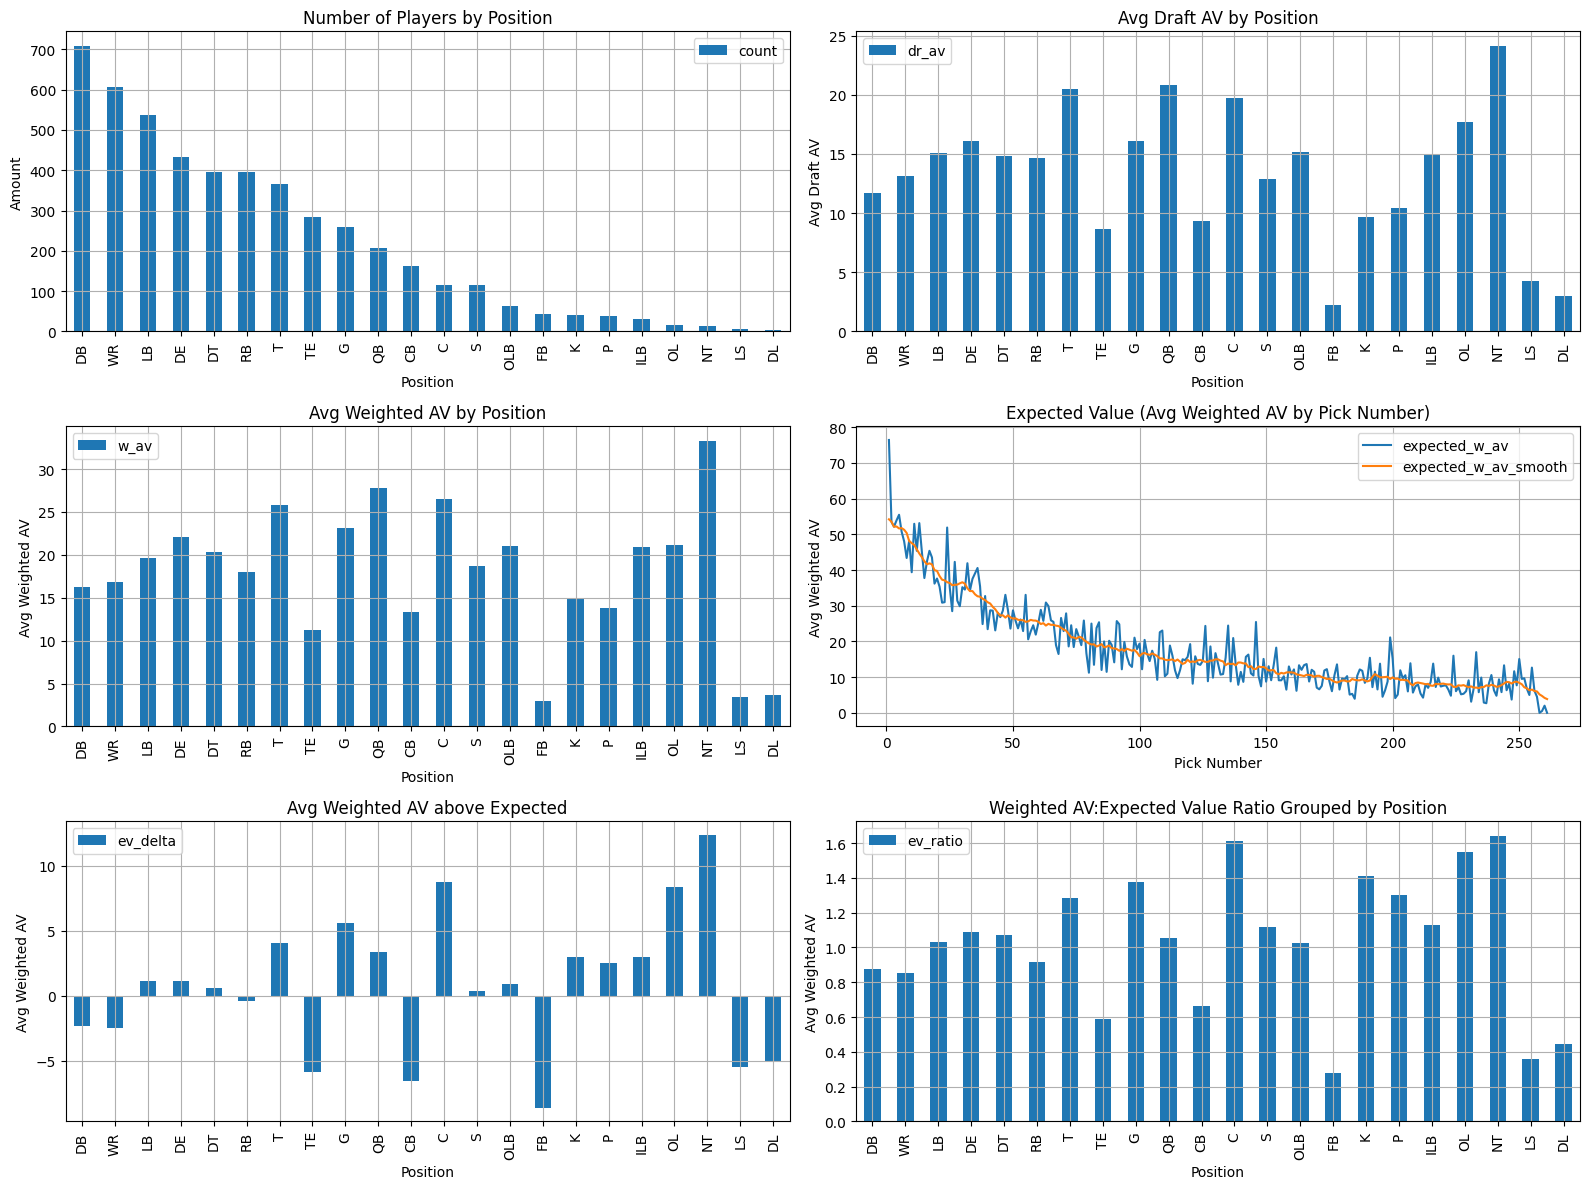

In [134]:

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

pos_counts.plot.bar(
    ax=axes[0, 0],
    title='Number of Players by Position',
    xlabel='Position',
    ylabel='Amount',
    grid=True,
)

pos_avg_dr_av.plot.bar(
    ax=axes[0, 1],
    title='Avg Draft AV by Position',
    xlabel='Position',
    ylabel='Avg Draft AV',
    grid=True,
)

pos_w_av.plot.bar(
    ax=axes[1, 0],
    title='Avg Weighted AV by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

expected.plot.line(
    ax=axes[1, 1],
    title='Expected Value (Avg Weighted AV by Pick Number)',
    xlabel='Pick Number',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ev_delta.plot.bar(
    ax=axes[2, 0],
    title='Avg Weighted AV above Expected',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ratio.plot.bar(
    ax=axes[2, 1],
    title='Weighted AV:Expected Value Ratio Grouped by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.tight_layout()
plt.show()

In [205]:
contracts_url = "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz"
contracts = pd.read_csv(contracts_url)
games = pd.read_csv('games (1).csv')
pfr_roster = pd.read_csv('pfr_rosters.csv')

C:\Users\SHANE\AppData\Local\Temp\ipykernel_16692\341449568.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  pfr_roster = pd.read_csv('pfr_rosters.csv')


In [206]:
games.groupby('season').size()

season
1999    259
2000    259
2001    259
2002    267
2003    267
2004    267
2005    267
2006    267
2007    267
2008    267
2009    267
2010    267
2011    267
2012    267
2013    267
2014    267
2015    267
2016    267
2017    267
2018    267
2019    267
2020    269
2021    285
2022    284
2023    285
2024    285
2025    285
dtype: int64

In [207]:
games = pd.DataFrame(games.loc[games['season'] >= 2002])

games = games.drop(columns=['away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'gameday', 'weekday',
       'gametime'])



games['home_win'] = (games['result'] > 0).astype(int)
games['away_loss'] = (games['result'] > 0).astype(int)
games['home_loss'] = (games['result'] < 0).astype(int)
games['away_win'] = (games['result'] < 0).astype(int)
games['home_tie'] = (games['result'] == 0).astype(int)
games['away_tie'] = (games['result'] == 0).astype(int)



home_wins = pd.DataFrame()
home_wins = games.groupby(['season', 'home_team'])['home_win'].sum().reset_index()
home_wins = home_wins.rename(columns={'home_team': 'team'})

away_wins = pd.DataFrame()
away_wins = games.groupby(['season', 'away_team'])['away_win'].sum().reset_index()
away_wins = away_wins.rename(columns={'away_team': 'team'})

home_loss = pd.DataFrame()
home_loss = games.groupby(['season', 'home_team'])['home_loss'].sum().reset_index()
home_loss = home_loss.rename(columns={'home_team': 'team'})

away_loss = pd.DataFrame()
away_loss = games.groupby(['season', 'away_team'])['away_loss'].sum().reset_index()
away_loss = away_loss.rename(columns={'away_team': 'team'})

ties_home = games.groupby(['season', 'home_team'])['home_tie'].sum().reset_index()
ties_home = ties_home.rename(columns={'home_team': 'team'})

ties_away = games.groupby(['season', 'away_team'])['away_tie'].sum().reset_index()
ties_away = ties_away.rename(columns={'away_team': 'team'})

In [208]:
seasons = pd.DataFrame()

seasons_win = pd.merge(home_wins, away_wins, on=['season', 'team'])
seasons_loss = pd.merge(home_loss, away_loss, on=['season', 'team'])
seasons_tie = pd.merge(ties_home, ties_away, on=['season', 'team'])

seasons_wl = pd.merge(seasons_win, seasons_loss, on=['season', 'team'])
seasons = pd.merge(seasons_wl, seasons_tie, on=['season', 'team'])

seasons['wins'] = seasons['home_win'] + seasons['away_win']
seasons['loss'] = seasons['home_loss'] + seasons['away_loss']
seasons['tie'] = seasons['home_tie'] + seasons['away_tie']
seasons['record'] = (
    seasons['wins'].astype(str) + '-' +
    seasons['loss'].astype(str) + '-' +
    seasons['tie'].astype(str)
)

seasons['games'] = seasons['tie'] + seasons['wins'] + seasons['loss']
seasons['playoffs'] = -1
seasons.loc[(seasons['games'] > 16) & (seasons['season'] < 2021), 'playoffs'] = 1
seasons.loc[seasons['games'] > 17, 'playoffs'] = 1
seasons.loc[seasons['games'] == 16, 'playoffs'] = 0
seasons.loc[(seasons['games'] == 17) & (seasons['season'] >= 2021), 'playoffs'] = 0

seasons.loc[seasons['team'] == 'OAK', 'team'] = 'LV'
seasons.loc[seasons['team'] == 'SD', 'team'] = 'LAC'
seasons.loc[seasons['team'] == 'STL', 'team'] = 'LA'

In [209]:
seasons['games'].value_counts().sort_index()

games
16    378
17    190
18    111
19     63
20     21
21      5
Name: count, dtype: int64

In [210]:
seasons.groupby('season')['games'].sum()

season
2002    534
2003    534
2004    534
2005    534
2006    534
2007    534
2008    534
2009    534
2010    534
2011    534
2012    534
2013    534
2014    534
2015    534
2016    534
2017    534
2018    534
2019    534
2020    538
2021    570
2022    568
2023    570
2024    570
2025    570
Name: games, dtype: int64

In [211]:
seasons['season'].value_counts()
seasons['playoffs'].value_counts()

playoffs
0    468
1    300
Name: count, dtype: int64

In [212]:
seasons.loc[(seasons['playoffs'] == 1) & (seasons['games'] == 21)].head(25)

,season,team,home_win,away_win,home_loss,away_loss,home_tie,away_tie,wins,loss,tie,record,games,playoffs
614,2021,CIN,6,7,5,3,0,0,13,8,0,13-8-0,21,1
624,2021,LA,7,9,3,2,0,0,16,5,0,16-5-0,21,1
687,2023,KC,7,8,4,2,0,0,15,6,0,15-6-0,21,1
729,2024,PHI,12,6,1,2,0,0,18,3,0,18-3-0,21,1
757,2025,NE,8,9,4,0,0,0,17,4,0,17-4-0,21,1


In [213]:
order_2022 = [
    # AFC East
    'BUF', 'MIA', 'NE', 'NYJ',
    # AFC North
    'CIN', 'BAL', 'PIT', 'CLE',
    # AFC South
    'JAX', 'TEN', 'IND', 'HOU',
    # AFC West
    'KC', 'LAC', 'LV', 'DEN',
    
    # NFC East
    'PHI', 'DAL', 'NYG', 'WAS',
    # NFC North
    'MIN', 'DET', 'GB', 'CHI',
    # NFC South
    'TB', 'CAR', 'NO', 'ATL',
    # NFC West
    'SF', 'SEA', 'LA', 'ARI'
]

In [214]:
df_2022 = seasons.loc[seasons['season'] == 2022].copy()

In [215]:
df_2022['team'] = pd.Categorical(df_2022['team'], categories=order_2022, ordered=True)

df_2022 = df_2022.sort_values('team')

In [216]:
print(df_2022[['team', 'wins', 'loss', 'tie', 'games', 'record', 'playoffs']])

    team  wins  loss  tie  games  record  playoffs
643  BUF    14     4    0     18  14-4-0         1
659  MIA     9     9    0     18   9-9-0         1
661   NE     8     9    0     17   8-9-0         0
664  NYJ     7    10    0     17  7-10-0         0
646  CIN    14     5    0     19  14-5-0         1
642  BAL    10     8    0     18  10-8-0         1
666  PIT     9     8    0     17   9-8-0         0
647  CLE     7    10    0     17  7-10-0         0
654  JAX    10     9    0     19  10-9-0         1
670  TEN     7    10    0     17  7-10-0         0
653  IND     4    12    1     17  4-12-1         0
652  HOU     3    13    1     17  3-13-1         0
655   KC    17     3    0     20  17-3-0         1
657  LAC    10     8    0     18  10-8-0         1
658   LV     6    11    0     17  6-11-0         0
649  DEN     5    12    0     17  5-12-0         0
665  PHI    16     4    0     20  16-4-0         1
648  DAL    13     6    0     19  13-6-0         1
663  NYG    10     8    1     1

In [199]:
seasons.loc[seasons['team'] == 'STL'].head()

,season,team,home_win,away_win,home_loss,away_loss,home_tie,away_tie,wins,loss,tie,record,games,playoffs
28,2002,STL,6,1,2,7,0,0,7,9,0,7-9-0,16,0
60,2003,STL,8,4,1,4,0,0,12,5,0,12-5-0,17,1
92,2004,STL,6,3,2,7,0,0,9,9,0,9-9-0,18,1
124,2005,STL,3,3,5,5,0,0,6,10,0,6-10-0,16,0
156,2006,STL,4,4,4,4,0,0,8,8,0,8-8-0,16,0


In [217]:
seasons['team'].value_counts()

team
ARI    24
ATL    24
BAL    24
BUF    24
CAR    24
CHI    24
CIN    24
CLE    24
DAL    24
DEN    24
DET    24
GB     24
HOU    24
IND    24
JAX    24
KC     24
MIA    24
MIN    24
NE     24
NO     24
NYG    24
NYJ    24
LV     24
PHI    24
PIT    24
LAC    24
SEA    24
SF     24
LA     24
TB     24
TEN    24
WAS    24
Name: count, dtype: int64

In [218]:
seasons.loc[(seasons['season'] == 2022) & (seasons['playoffs'] == 1)].head(35)

,season,team,home_win,away_win,home_loss,away_loss,home_tie,away_tie,wins,loss,tie,record,games,playoffs
642,2022,BAL,5,5,3,5,0,0,10,8,0,10-8-0,18,1
643,2022,BUF,8,6,2,2,0,0,14,4,0,14-4-0,18,1
646,2022,CIN,7,7,1,4,0,0,14,5,0,14-5-0,19,1
648,2022,DAL,8,5,1,5,0,0,13,6,0,13-6-0,19,1
654,2022,JAX,6,4,3,6,0,0,10,9,0,10-9-0,19,1
655,2022,KC,9,8,1,2,0,0,17,3,0,17-3-0,20,1
657,2022,LAC,5,5,3,5,0,0,10,8,0,10-8-0,18,1
659,2022,MIA,6,3,2,7,0,0,9,9,0,9-9-0,18,1
660,2022,MIN,8,5,2,3,0,0,13,5,0,13-5-0,18,1
663,2022,NYG,5,5,3,5,1,0,10,8,1,10-8-1,19,1


In [ ]:
# 2020 was final year of 16 games. Do flag of playoff games based on playing more than regular season amount. 
# also need win percentage, and possibly avg score differential per game as well as off ppg and def ppg


# Bills and Bengals had Damar Hamlin game cancelled in 2022